# AI Ay Ay - Final Project Illustration: Written/Spoken Language Classification

# Project Goals

This project was designed to be practical in use: an AI model capable of efficiently and quickly identifying and labeling the typed/spoken language. We figured this was a useful endevour to pursue, as most translation tools depend on pre-selecting languages to translate "from" and "to", while this model would be able to identify languages without any kind of prior knowledge.

# Datasets

In the training of our models, we used two datasets:

### Language Identification Dataset
https://www.kaggle.com/datasets/zarajamshaid/language-identification-datasst

The **Language Identification Dataset** contains 1,000 rows/paragraphs for each of the labeled languages.

### Language Detection Dataset
https://www.kaggle.com/datasets/basilb2s/language-detection

The **Language Detection Dataset** consists of text and 17 language labels.


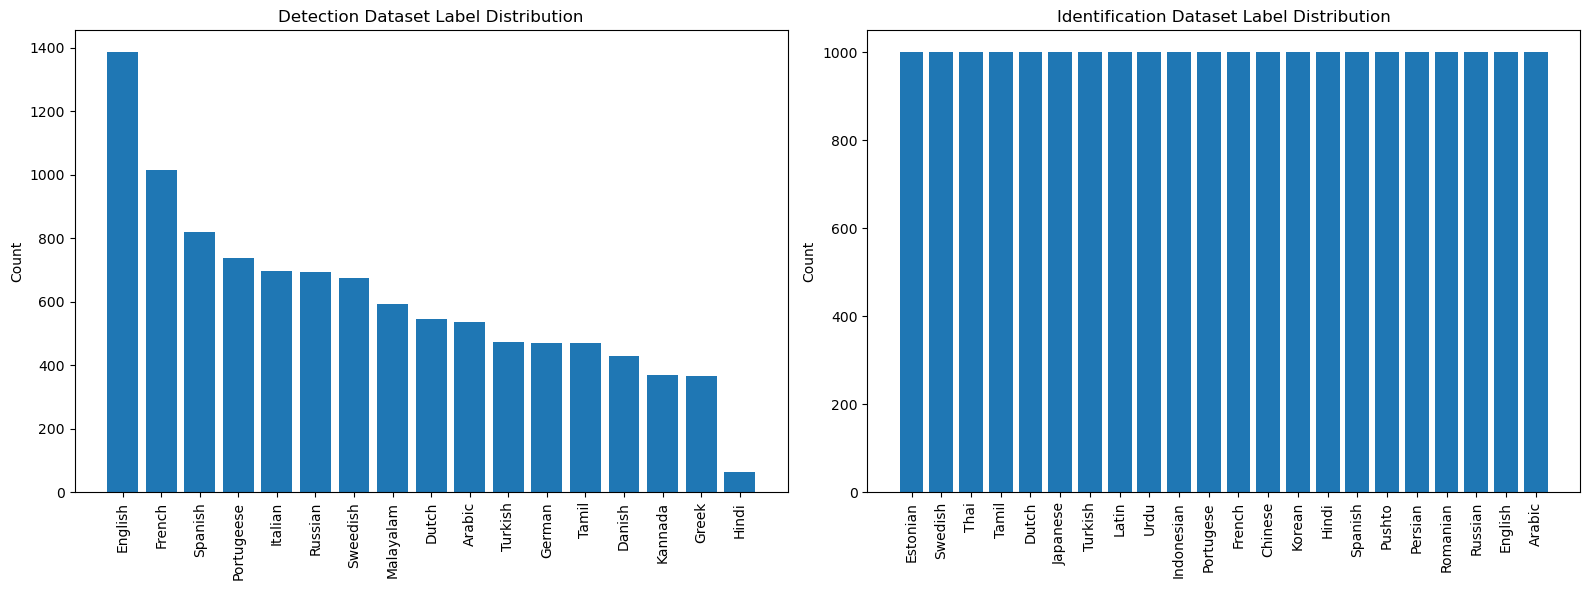

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# load datasets
detection_df = pd.read_csv("Data/Detection.csv")
identification_df = pd.read_csv("Data/Identification.csv")

# count labels
det_counts = detection_df["Language"].value_counts().sort_values(ascending=False)
id_counts  = identification_df["language"].value_counts().sort_values(ascending=False)

# create figure
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# detection dataset
axes[0].bar(det_counts.index, det_counts.values)
axes[0].set_title("Detection Dataset Label Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=90)

# identification dataset
axes[1].bar(id_counts.index, id_counts.values)
axes[1].set_title("Identification Dataset Label Distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Evaluation of Datasets

It is important to recognize the Detection Dataset's bias towards English, in contrast to the Identification's uniform distribution.

Both were combined, however, and standardized to become a new, useful dataset with a total of 28 languages, and a slightly more uniform structure. There is a concerning tail (Greek, Kannada, Danish, German...) that may explain some of the results discussed later.

Rows before cleaning: 32129
Rows after cleaning: 31184


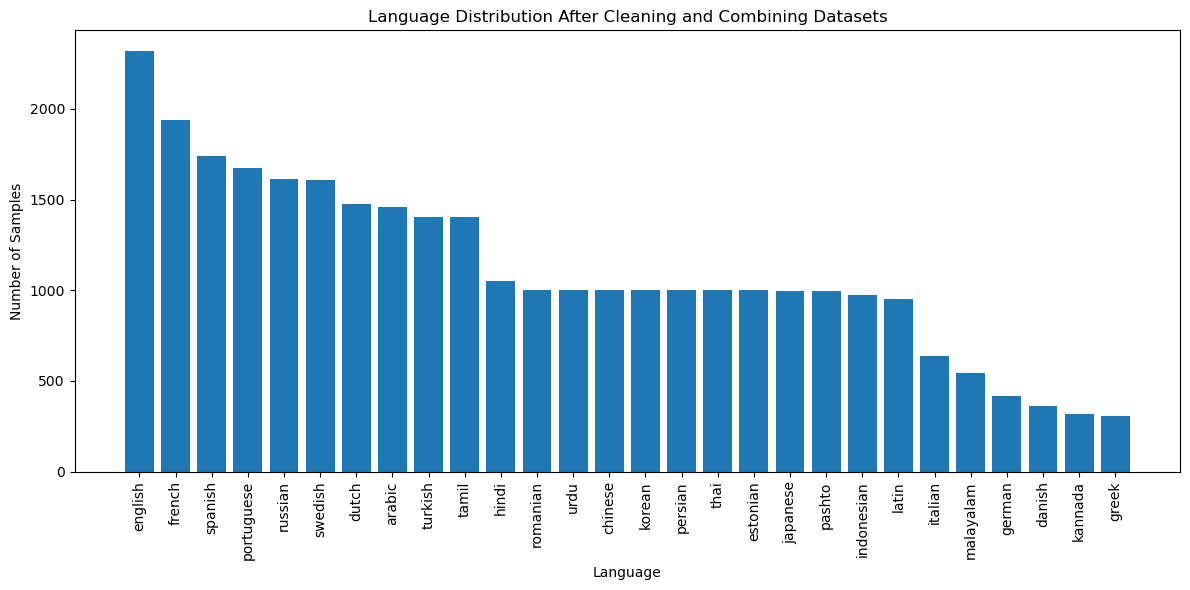

In [2]:
import matplotlib.pyplot as plt
from src.datamanager import *

# load and combine
combined = load_and_combine(
    "Data/Detection.csv",
    "Data/Identification.csv"
)

# clean the dataset
cleaned = basic_clean_and_filter(combined)

print("Rows before cleaning:", len(combined))
print("Rows after cleaning:", len(cleaned))

# count labels
label_counts = cleaned["label"].value_counts().sort_values(ascending=False)

# plot
plt.figure(figsize=(12,6))
plt.bar(label_counts.index, label_counts.values)

plt.title("Language Distribution After Cleaning and Combining Datasets")
plt.xlabel("Language")
plt.ylabel("Number of Samples")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Model Results

# Baseline

There were two simple models implemented as a baseline:

    1. Logistic Regression trained via TF-IDF Vectorization

    2. Gemma LLM


### Logistic Regression + TF-IDF Evaluation
Let's begin our evaluation of these two models by looking at the **Logistic Regression + TF-IDF Model** first. Since this model is pretrained, we can load and evaluate it in real-time by running the code block below:

Loading trained model...


/opt/anaconda3/envs/cs175/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/cs175/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/cs175/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.5.1 when using

Reloading dataset...
Vectorizing test set...
Predicting...
Test Accuracy: 0.9891447368421052


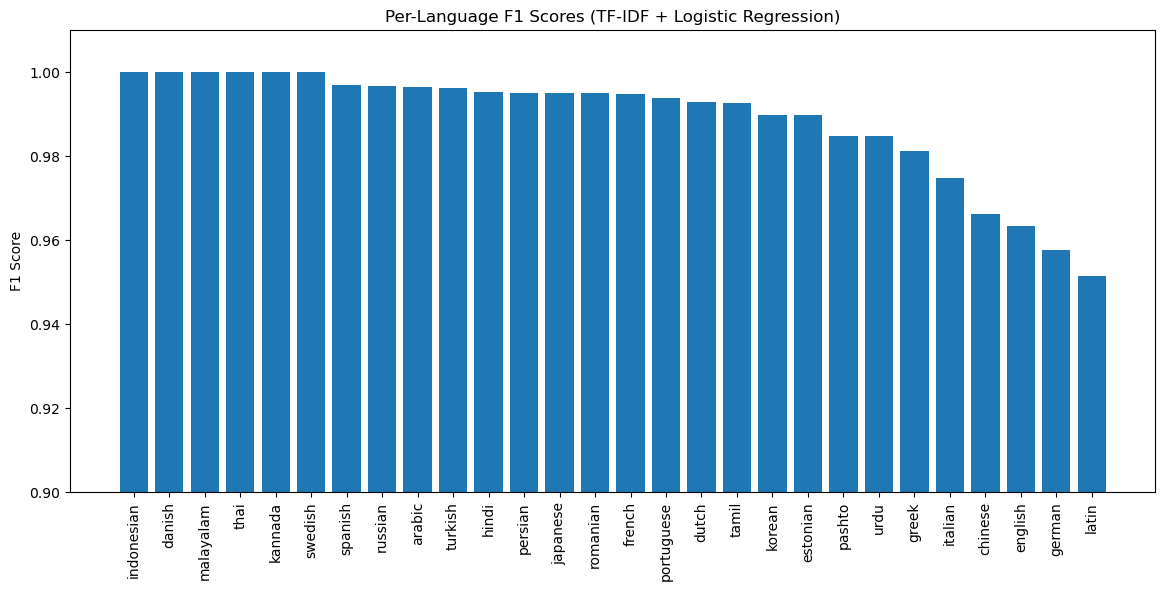

In [3]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from src.datamanager import load_and_combine, basic_clean_and_filter, stratified_split
from sklearn.metrics import accuracy_score, classification_report

print("Loading trained model...")
bundle = joblib.load("artifacts/language_pipeline.joblib")

model = bundle["model"]
vectorizer = bundle["vectorizer"]

print("Reloading dataset...")
df = load_and_combine("Data/Detection.csv", "Data/Identification.csv")
df = basic_clean_and_filter(df, min_chars=30, max_chars=600)

train_df, val_df, test_df = stratified_split(df, seed=0)

print("Vectorizing test set...")
X_test = vectorizer.transform(test_df["text"])

print("Predicting...")
preds = model.predict(X_test)

print("Test Accuracy:", accuracy_score(test_df["label"], preds))

# Convert classification report to dictionary
report = classification_report(test_df["label"], preds, output_dict=True)

# Convert to dataframe
report_df = pd.DataFrame(report).transpose()

# Remove average rows
report_df = report_df.drop(["accuracy", "macro avg", "weighted avg"])

# Sort by F1 score
report_df = report_df.sort_values("f1-score", ascending=False)

# Plot
plt.figure(figsize=(14,6))
plt.bar(report_df.index, report_df["f1-score"])

plt.title("Per-Language F1 Scores (TF-IDF + Logistic Regression)")
plt.ylabel("F1 Score")
plt.xticks(rotation=90)
plt.ylim(0.90, 1.01)

plt.show()

We can additionally run a test with this baseline model via the utilization of an <u>entirely new dataset!</u> Introducing: Huggingface Language Identification Data (https://huggingface.co/datasets/papluca/language-identification)

/opt/anaconda3/envs/cs175/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/cs175/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/cs175/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.5.1 when using

Accuracy: 0.9309027777777777


/opt/anaconda3/envs/cs175/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cs175/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cs175/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sha

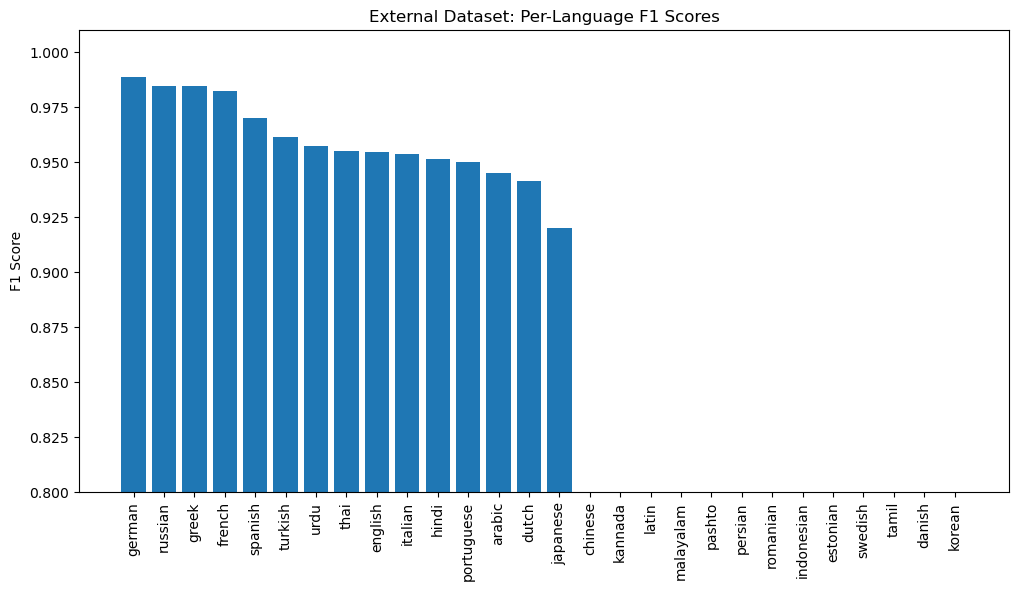


Predictions for unseen languages:

--- bulgarian (n=4500) ---
prediction
russian    0.953333
chinese    0.046667
Name: proportion, dtype: float64

--- polish (n=4500) ---
prediction
chinese       0.973333
german        0.011111
portuguese    0.005778
english       0.004222
estonian      0.002667
italian       0.001333
latin         0.000889
french        0.000444
dutch         0.000222
Name: proportion, dtype: float64

--- swahili (n=4500) ---
prediction
chinese       0.483778
estonian      0.267111
turkish       0.172444
english       0.063111
indonesian    0.006222
italian       0.002444
spanish       0.001778
portuguese    0.001556
latin         0.000667
french        0.000667
Name: proportion, dtype: float64

--- vietnamese (n=4500) ---
prediction
chinese       0.884444
english       0.098000
indonesian    0.008444
italian       0.003778
french        0.001556
spanish       0.001556
portuguese    0.001111
german        0.000444
swedish       0.000444
danish        0.000222
Name: p

In [4]:
from src.full_dataset_tester import get_new_dataset, fix_labels, analyze_unseen_languages
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

bundle = joblib.load("artifacts/language_pipeline.joblib")
model = bundle["model"]
vectorizer = bundle["vectorizer"]

full_df = get_new_dataset()
df = fix_labels(full_df.copy())

X = vectorizer.transform(df["text"])
preds = model.predict(X)

df["prediction"] = preds

print("Accuracy:", accuracy_score(df["mapped_label"], preds))

# Generate classification report
report = classification_report(
    df["mapped_label"],
    preds,
    labels=model.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Remove average rows
report_df = report_df.drop(["accuracy", "macro avg", "weighted avg"])

# Sort by F1
report_df = report_df.sort_values("f1-score", ascending=False)

# Plot F1 scores
plt.figure(figsize=(12,6))
plt.bar(report_df.index, report_df["f1-score"])

plt.title("External Dataset: Per-Language F1 Scores")
plt.ylabel("F1 Score")
plt.xticks(rotation=90)
plt.ylim(0.8, 1.01)

plt.show()

# analyze unseen languages
analyze_unseen_languages(full_df, model, vectorizer)

### Discussion - Logistic Regression + TF-IDF

With the initial test set, we can see an accuracy rate of 98%, which is incredible for a rather simple baseline model of ours. We hit the ground running, and to confirm that were true, we went further and tested the model on an entirely new dataset. This new dataset demonstrates a slightly lower accuracy of only 93%.

Secondly, we noticed this new dataset contained four languages the model was not trained on. While these languages were excluded when testing the accuracy of our model, we tested them separately to examine the behavior of our model. Strangely, for each of these languages (except Bulgarian), Chinese has a incredibly high confidence level.

It appears that Chinese script's unique 40,000 characters create a very sparse TF-IDF vectorization, and when an unknown language enters the scene, the high positive values of all the unique Chinese n-grams become very strong pull factors.

### Gemma LLM - Evaluation

Now let's take a look at our experiments with Gemma LLM, the results are not so great.

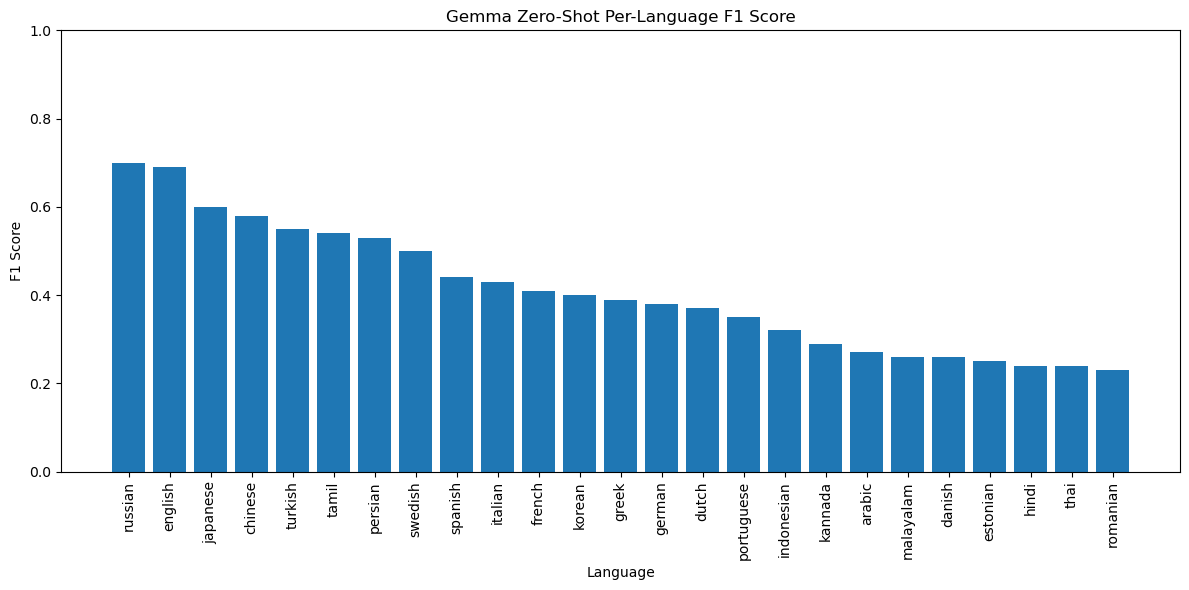

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

gemma_data = [
    ("arabic", 0.27),
    ("chinese", 0.58),
    ("danish", 0.26),
    ("dutch", 0.37),
    ("english", 0.69),
    ("estonian", 0.25),
    ("french", 0.41),
    ("german", 0.38),
    ("greek", 0.39),
    ("hindi", 0.24),
    ("indonesian", 0.32),
    ("italian", 0.43),
    ("japanese", 0.60),
    ("kannada", 0.29),
    ("korean", 0.40),
    ("malayalam", 0.26),
    ("persian", 0.53),
    ("portuguese", 0.35),
    ("romanian", 0.23),
    ("russian", 0.70),
    ("spanish", 0.44),
    ("swedish", 0.50),
    ("tamil", 0.54),
    ("thai", 0.24),
    ("turkish", 0.55)
]

df = pd.DataFrame(gemma_data, columns=["language", "f1"])
df = df.sort_values("f1", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(df["language"], df["f1"])

plt.title("Gemma Zero-Shot Per-Language F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("Language")
plt.xticks(rotation=90)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

The F1 scores are pretty low, and accuracy is much lower than those from the Logistic Regression + TF-IDF model. Let's compare the accuracies for all three tests done together:

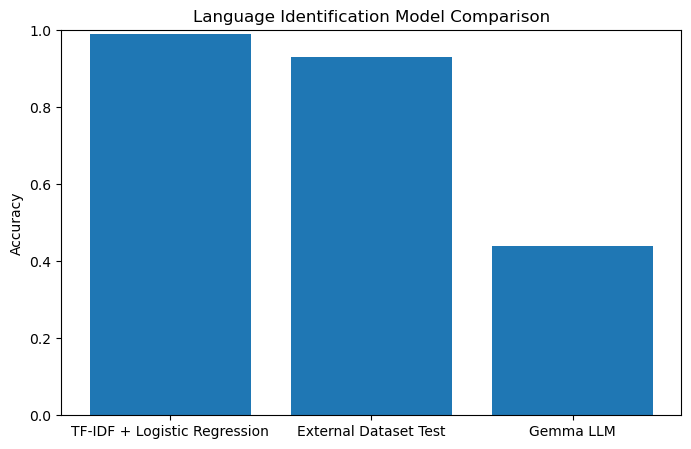

In [6]:
import matplotlib.pyplot as plt

models = [
    "TF-IDF + Logistic Regression",
    "External Dataset Test",
    "Gemma LLM"
]

accuracies = [
    0.9891,
    0.9309,
    0.44
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Language Identification Model Comparison")
plt.ylim(0,1)

plt.show()

### Gemma LLM - Discussion

It appears that Gemma LLM is not particularly specialized in classification tasks, which explains it's poor behavior. These prompts were unsupervised, and hard to fine-tune. The sample size may have been too small as well. Despite all this, it appears the LLM would require expensive, time-consuming work to fine-tune, and when compared to the already high results from our other baseline, it does not prove to be worth exploring as an option

# Naive Bayes

We also explored a Naive Bayes model, trained with the data vectorized in **three different ways**:

    1. TF-IDF

    2. Bag-of-Words

    3. N-Grams

While we do not have the pre-trained model, we have saved results and can go through them here.

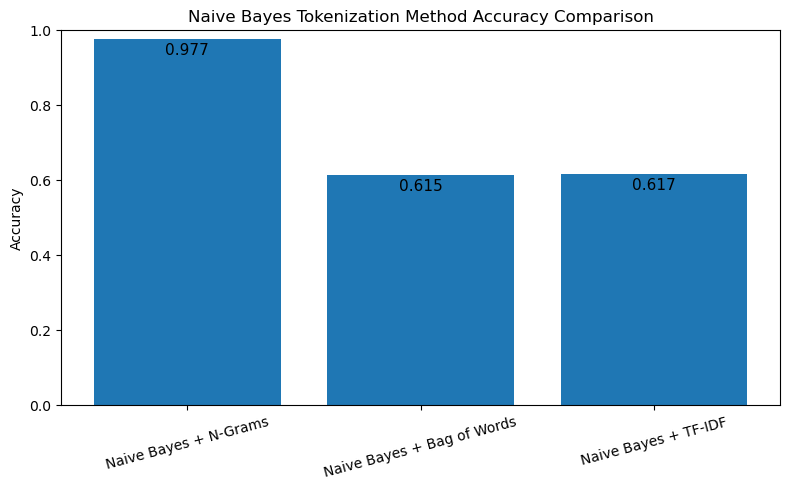

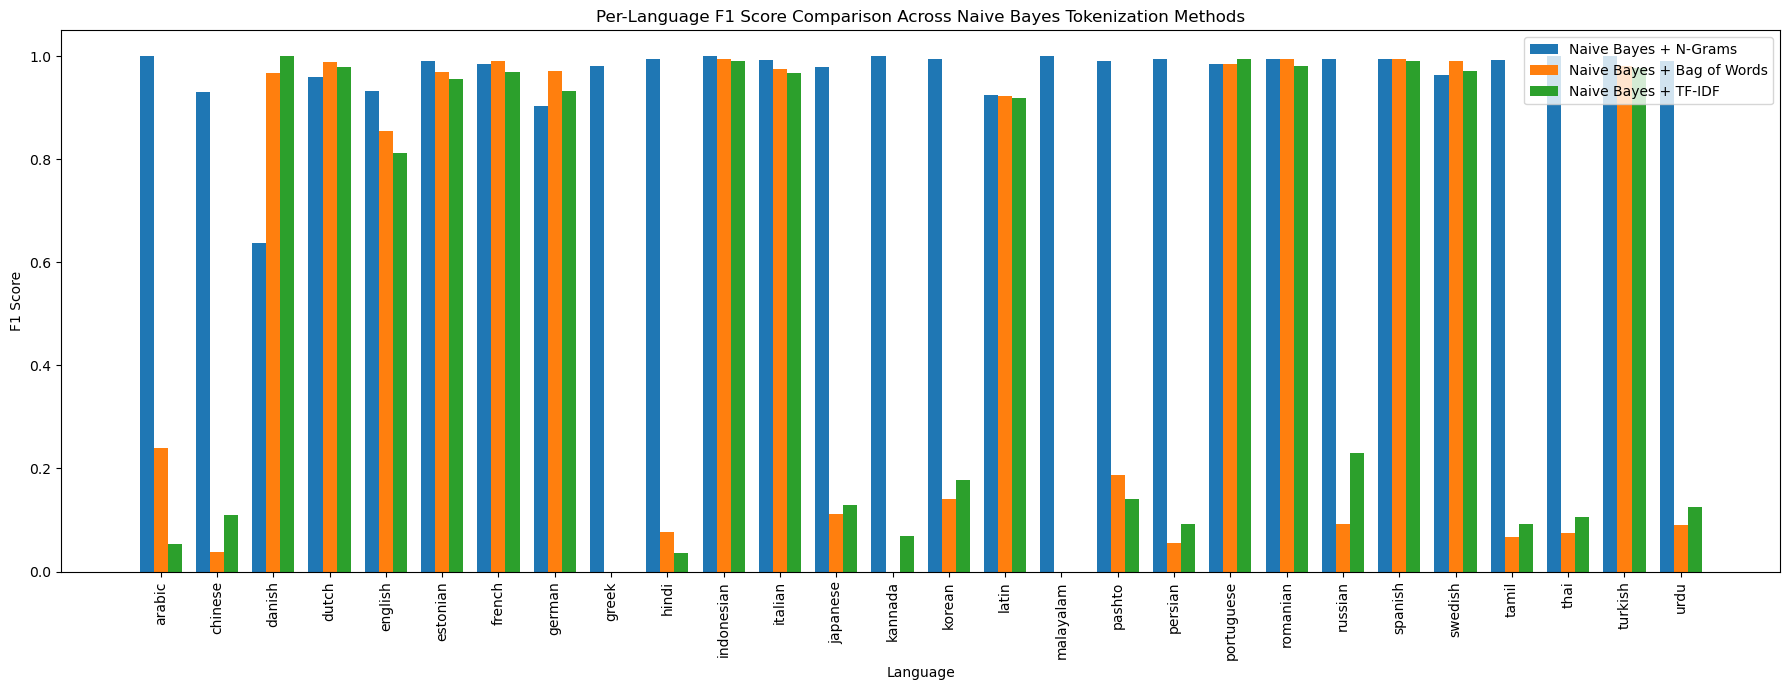

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

accuracy_data = {
    "Model": [
        "Naive Bayes + N-Grams",
        "Naive Bayes + Bag of Words",
        "Naive Bayes + TF-IDF"
    ],
    "Accuracy": [0.9770, 0.6145, 0.6171]
}

acc_df = pd.DataFrame(accuracy_data)

plt.figure(figsize=(8,5))

bars = plt.bar(acc_df["Model"], acc_df["Accuracy"])

plt.title("Naive Bayes Tokenization Method Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height - 0.05,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

ngram_f1 = {
    "arabic": 1.0000,
    "chinese": 0.9305,
    "danish": 0.6383,
    "dutch": 0.9586,
    "english": 0.9320,
    "estonian": 0.9899,
    "french": 0.9845,
    "german": 0.9032,
    "greek": 0.9811,
    "hindi": 0.9952,
    "indonesian": 1.0000,
    "italian": 0.9915,
    "japanese": 0.9796,
    "kannada": 1.0000,
    "korean": 0.9950,
    "latin": 0.9239,
    "malayalam": 1.0000,
    "pashto": 0.9899,
    "persian": 0.9950,
    "portuguese": 0.9846,
    "romanian": 0.9950,
    "russian": 0.9936,
    "spanish": 0.9940,
    "swedish": 0.9627,
    "tamil": 0.9926,
    "thai": 1.0000,
    "turkish": 1.0000,
    "urdu": 0.9899
}

bow_f1 = {
    "arabic": 0.2390,
    "chinese": 0.0385,
    "danish": 0.9677,
    "dutch": 0.9893,
    "english": 0.8539,
    "estonian": 0.9694,
    "french": 0.9896,
    "german": 0.9714,
    "greek": 0.0000,
    "hindi": 0.0775,
    "indonesian": 0.9948,
    "italian": 0.9748,
    "japanese": 0.1121,
    "kannada": 0.0000,
    "korean": 0.1404,
    "latin": 0.9231,
    "malayalam": 0.0000,
    "pashto": 0.1875,
    "persian": 0.0561,
    "portuguese": 0.9846,
    "romanian": 0.9950,
    "russian": 0.0925,
    "spanish": 0.9940,
    "swedish": 0.9904,
    "tamil": 0.0662,
    "thai": 0.0748,
    "turkish": 0.9814,
    "urdu": 0.0909
}

tfidf_f1 = {
    "arabic": 0.0533,
    "chinese": 0.1101,
    "danish": 1.0000,
    "dutch": 0.9787,
    "english": 0.8116,
    "estonian": 0.9557,
    "french": 0.9692,
    "german": 0.9315,
    "greek": 0.0000,
    "hindi": 0.0357,
    "indonesian": 0.9897,
    "italian": 0.9667,
    "japanese": 0.1284,
    "kannada": 0.0690,
    "korean": 0.1770,
    "latin": 0.9189,
    "malayalam": 0.0000,
    "pashto": 0.1404,
    "persian": 0.0926,
    "portuguese": 0.9939,
    "romanian": 0.9802,
    "russian": 0.2296,
    "spanish": 0.9911,
    "swedish": 0.9718,
    "tamil": 0.0915,
    "thai": 0.1062,
    "turkish": 0.9778,
    "urdu": 0.1261
}

ngram_df = pd.DataFrame(list(ngram_f1.items()), columns=["language", "ngram_f1"])
bow_df = pd.DataFrame(list(bow_f1.items()), columns=["language", "bow_f1"])
tfidf_df = pd.DataFrame(list(tfidf_f1.items()), columns=["language", "tfidf_f1"])

# Merge
combined = ngram_df.merge(bow_df, on="language").merge(tfidf_df, on="language")

combined = combined.sort_values("language").reset_index(drop=True)

# Grouped bar chart
x = np.arange(len(combined))
width = 0.25

plt.figure(figsize=(18, 7))
plt.bar(x - width, combined["ngram_f1"], width, label="Naive Bayes + N-Grams")
plt.bar(x, combined["bow_f1"], width, label="Naive Bayes + Bag of Words")
plt.bar(x + width, combined["tfidf_f1"], width, label="Naive Bayes + TF-IDF")

plt.xticks(x, combined["language"], rotation=90)
plt.ylabel("F1 Score")
plt.xlabel("Language")
plt.title("Per-Language F1 Score Comparison Across Naive Bayes Tokenization Methods")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

### Naive Bayes - Discussion

From looking at the accuracy comparisons alone, we can see that N-Grams blows the other two vectoriation models out of the water! This most likely stems from the superiority of grouping together commonly used phrases and terms, rather than taking a look at each word on its own.

# BERT MODEL

The BERT Model analyzes words bi-directionally (left-and-right) which aims to analyze the context of human language. This seems perfect for our goal, so let's explore the results of our high-dimensional model:

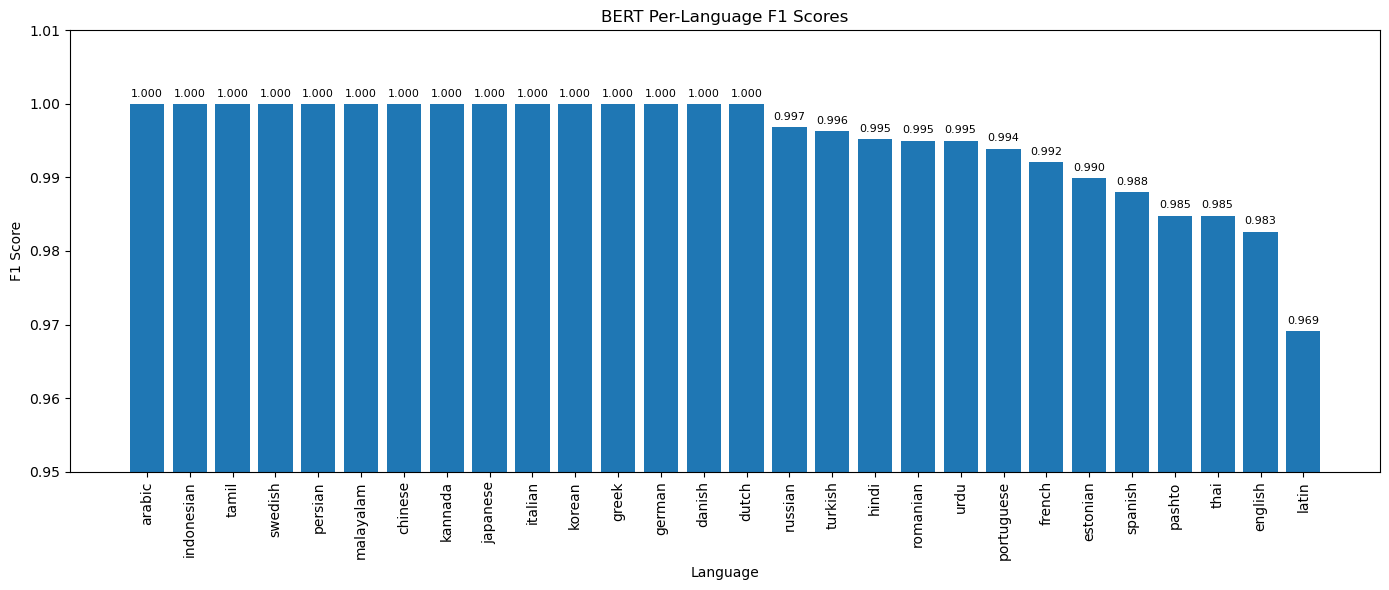

BERT Test Accuracy: 0.9941 (99.41%)


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

bert_data = [
("arabic",1.0000),("chinese",1.0000),("danish",1.0000),("dutch",1.0000),
("english",0.9826),("estonian",0.9899),("french",0.9921),("german",1.0000),
("greek",1.0000),("hindi",0.9952),("indonesian",1.0000),("italian",1.0000),
("japanese",1.0000),("kannada",1.0000),("korean",1.0000),("latin",0.9691),
("malayalam",1.0000),("pashto",0.9848),("persian",1.0000),("portuguese",0.9939),
("romanian",0.9950),("russian",0.9968),("spanish",0.9880),("swedish",1.0000),
("tamil",1.0000),("thai",0.9848),("turkish",0.9963),("urdu",0.9950)
]

df = pd.DataFrame(bert_data, columns=["language","f1"])
df = df.sort_values("f1", ascending=False)

plt.figure(figsize=(14,6))
bars = plt.bar(df["language"], df["f1"])

plt.title("BERT Per-Language F1 Scores")
plt.ylabel("F1 Score")
plt.xlabel("Language")
plt.xticks(rotation=90)
plt.ylim(0.95,1.01)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.001, f"{h:.3f}",
             ha='center', fontsize=8)

plt.tight_layout()
plt.show()

accuracy = 0.994075
print(f"BERT Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

### BERT Model - Discussion

The BERT Model did remarkable; achieving a 99.41% in accuracy! It takes advantage of the unique scripts of certain languages, obtaining 100% accuracy for those languages that use such unique scripts, like Arabic and Chinese. This method is demonstrated to not be as reliable for languages with shared scripts, like English and Latin at the tail end of the F1 Scores, but still succeeds in maintaing above a 95% accuracy for all languages despite this.

It's very easy to see that this well-trained model does remarkably well, and is worth the effort of training on such a large corpus.

# Conclusion: Textual Model Accuracies

Now that we have reviewed all models, let's compare their accuracies in one graph:

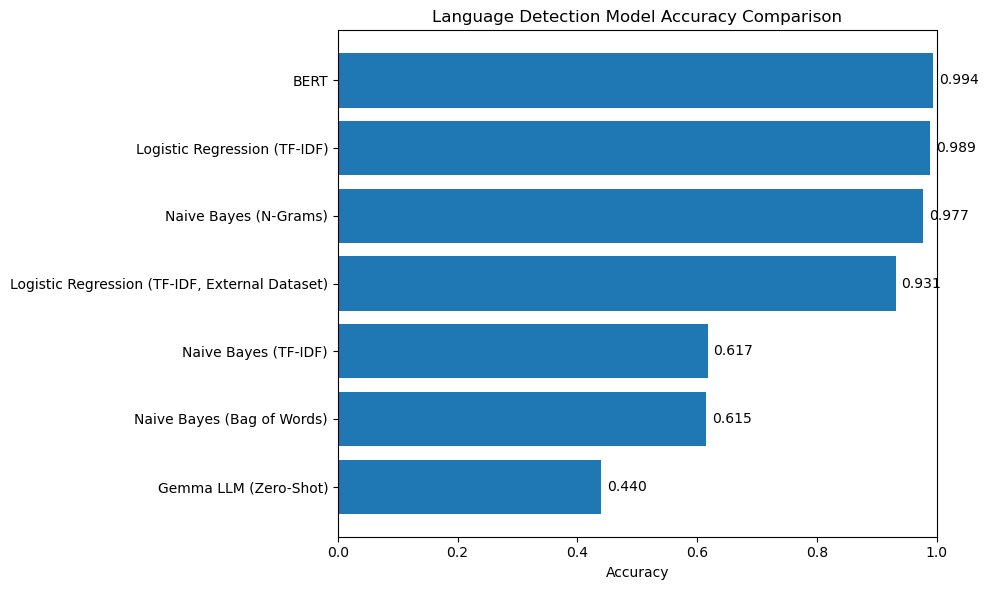

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

accuracy_data = {
    "Model": [
        "BERT",
        "Logistic Regression (TF-IDF)",
        "Logistic Regression (TF-IDF, External Dataset)",
        "Naive Bayes (N-Grams)",
        "Naive Bayes (Bag of Words)",
        "Naive Bayes (TF-IDF)",
        "Gemma LLM (Zero-Shot)"
    ],
    "Accuracy": [
        0.994075,
        0.9891447368421052,
        0.9309027777777777,
        0.9770,
        0.6145,
        0.6171,
        0.44
    ]
}

df = pd.DataFrame(accuracy_data)

df = df.sort_values("Accuracy")

plt.figure(figsize=(10,6))
bars = plt.barh(df["Model"], df["Accuracy"])

plt.title("Language Detection Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.xlim(0,1)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01,
             bar.get_y() + bar.get_height()/2,
             f"{width:.3f}",
             va='center')

plt.tight_layout()
plt.show()

# Demo
Now that we've demonstarted, plotted, and evaluated all our models, let's have some fun! Below is a little implementation that utilizes a terminal-based program that allows a user to mess around with one of our pre-trained models (TF-IDF)

In [11]:
import src.terminal_interface

src.terminal_interface.main()

"""Note: The demo runs a bit strange if you try and run the jupyter notebook from within PyCharm. Try running
it within a Jupyter Notebook tab itself and it should be fine."""

/opt/anaconda3/envs/cs175/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/cs175/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Language classifier ready.
(Val acc: 0.9852 | Test acc: 0.9891)
Type text and press Enter. Type /quit to exit.


/opt/anaconda3/envs/cs175/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Predicted: chinese  (confidence: 0.112)
Predicted: chinese  (confidence: 0.122)
Predicted: spanish  (confidence: 0.209)
Predicted: english  (confidence: 0.130)
Please type a bit more text (10+ chars) for a reliable prediction.
Please type a bit more text (10+ chars) for a reliable prediction.
